

**1. Drive Mounting**




In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



**2.Project Path**



In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/Audio_project_CRNN_GRU"

DATASET_DIR = os.path.join(BASE_DIR, "Dataset_audio")
SCREAM_DIR = os.path.join(DATASET_DIR, "scream")
NON_SCREAM_DIR = os.path.join(DATASET_DIR, "non_scream")

MODEL_DIR = os.path.join(BASE_DIR, "Model")
CHECKPOINT_DIR = os.path.join(MODEL_DIR, "checkpoints")
BEST_MODEL_DIR = os.path.join(MODEL_DIR, "best_model")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(BEST_MODEL_DIR, exist_ok=True)


In [3]:
import librosa
import numpy as np

def extract_mel(file_path, max_len=128):
    audio, sr = librosa.load(file_path, sr=22050)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128,
        hop_length=512
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # truncateing
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, pad_width=((0,0),(0,pad_width)))
    else:
        mel_db = mel_db[:, :max_len]

    return mel_db


In [4]:
X = []
y = []

# Scream = 1
for file in os.listdir(SCREAM_DIR):
    if file.endswith(".wav"):
        path = os.path.join(SCREAM_DIR, file)
        X.append(extract_mel(path))
        y.append(1)

# Non-scream = 0
for file in os.listdir(NON_SCREAM_DIR):
    if file.endswith(".wav"):
        path = os.path.join(NON_SCREAM_DIR, file)
        X.append(extract_mel(path))
        y.append(0)

X = np.array(X)
y = np.array(y)

# channel dimension for CNN
X = X[..., np.newaxis]

print("Dataset shape:", X.shape)


Dataset shape: (3128, 128, 128, 1)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Reshape, GRU, Dense, Dropout

model = Sequential()

# CNN
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Prepare for GRU
model.add(Reshape((32, -1)))

# GRU
model.add(GRU(64))

# Dense
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 1800)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │       358,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 379,201 (1.45 MB)

 Trainable params: 379,201 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "epoch_{epoch:02d}_valLoss_{val_loss:.4f}.h5"),
    save_weights_only=False,
    save_best_only=False,
    verbose=1
)

best_model_cb = ModelCheckpoint(
    filepath=os.path.join(BEST_MODEL_DIR, "best_model.h5"),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[checkpoint_cb, best_model_cb, early_stop_cb]
)


Epoch 1/30
153/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7330 - loss: 0.5597
Epoch 1: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_01_valLoss_0.5502.h5



Epoch 1: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7317 - loss: 0.5609 - val_accuracy: 0.7604 - val_loss: 0.5502
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7112 - loss: 0.6082
Epoch 2: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_02_valLoss_0.5310.h5



Epoch 2: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7112 - loss: 0.6082 - val_accuracy: 0.7732 - val_loss: 0.5310
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7094 - loss: 0.6073
Epoch 3: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_03_valLoss_0.5619.h5



Epoch 3: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7093 - loss: 0.6073 - val_accuracy: 0.7700 - val_loss: 0.5619
Epoch 4/30
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7032 - loss: 0.6146
Epoch 4: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_04_valLoss_0.5637.h5



Epoch 4: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7033 - loss: 0.6145 - val_accuracy: 0.7716 - val_loss: 0.5637
Epoch 5/30
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7199 - loss: 0.5986
Epoch 5: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_05_valLoss_0.5643.h5



Epoch 5: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7198 - loss: 0.5986 - val_accuracy: 0.7540 - val_loss: 0.5643
Epoch 6/30
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7231 - loss: 0.5942
Epoch 6: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_06_valLoss_0.5461.h5



Epoch 6: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7232 - loss: 0.5942 - val_accuracy: 0.7764 - val_loss: 0.5461
Epoch 7/30
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7255 - loss: 0.5993
Epoch 7: saving model to /content/drive/MyDrive/Audio_project_CRNN_GRU/Model/checkpoints/epoch_07_valLoss_0.5454.h5



Epoch 7: val_loss did not improve from 0.47943
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7255 - loss: 0.5992 - val_accuracy: 0.7668 - val_loss: 0.5454


In [12]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)


In [13]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/content/drive/MyDrive/Audio_project_CRNN_GRU/Model/best_model/best_model.h5"
)


In [14]:
import numpy as np

y_prob = best_model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


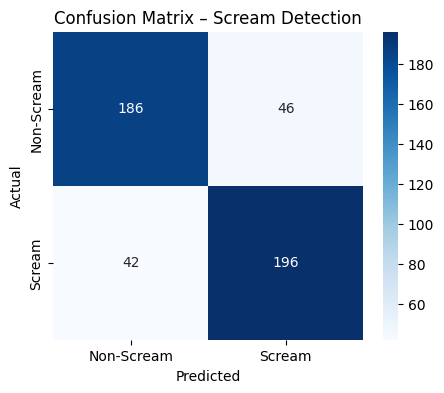

              precision    recall  f1-score   support

  Non-Scream       0.82      0.80      0.81       232
      Scream       0.81      0.82      0.82       238

    accuracy                           0.81       470
   macro avg       0.81      0.81      0.81       470
weighted avg       0.81      0.81      0.81       470



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Scream", "Scream"],
            yticklabels=["Non-Scream", "Scream"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Scream Detection")
plt.show()

print(classification_report(y_test, y_pred, target_names=["Non-Scream", "Scream"]))


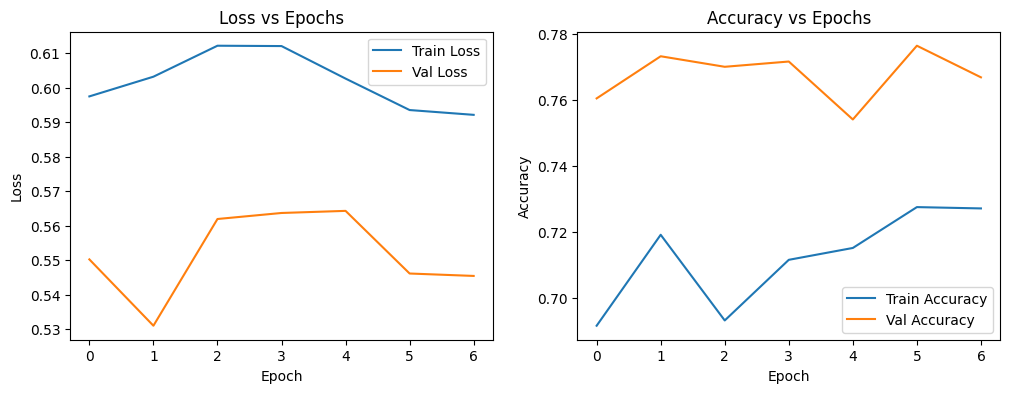

In [16]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()
